In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
df_unlcean = pd.read_csv('canada_trade.csv',index_col=False)

In [4]:
df_unlcean.shape

(6704, 47)

In [5]:
df_unlcean.dtypes

typeCode                     object
freqCode                     object
refPeriodId                   int64
refYear                       int64
refMonth                      int64
period                        int64
reporterCode                  int64
reporterISO                  object
reporterDesc                 object
flowCode                     object
flowDesc                     object
partnerCode                   int64
partnerISO                   object
partnerDesc                  object
partner2Code                  int64
partner2ISO                  object
partner2Desc                 object
classificationCode           object
classificationSearchCode     object
isOriginalClassification       bool
cmdCode                       int64
cmdDesc                      object
aggrLevel                     int64
isLeaf                         bool
customsCode                  object
customsDesc                  object
mosCode                       int64
motCode                     

In [6]:
df_unlcean.head(3)

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20190101,2019,52,2019,124,CAN,Canada,M,...,NaN,False,0,False,NaN,4.278093e+08,4.278093e+08,0,False,True
1,C,A,20190101,2019,52,2019,124,CAN,Canada,M,...,NaN,False,0,False,NaN,4.010446e+09,4.010446e+09,0,False,True
2,C,A,20190101,2019,52,2019,124,CAN,Canada,M,...,NaN,False,0,False,NaN,2.157018e+09,2.157018e+09,0,False,True


In [7]:
df = df_unlcean[['refYear','flowDesc','partnerDesc','cmdCode','cmdDesc','primaryValue']].copy()

In [8]:
df.columns = ['year','flow','country','cmdCode','commodity','value_usd']

In [9]:
print(df.shape)
print(df['flow'].unique())
print(df['year'].unique())
print(df.isnull().sum())

(6704, 6)
['Import' 'Export']
[2019 2020 2021 2022 2023]
year         0
flow         0
country      0
cmdCode      0
commodity    0
value_usd    0
dtype: int64


In [10]:
# Remove aggregate rows 
df_clean = df[~df['country'].isin(['World','Canada'])].copy()
df_clean = df_clean[df_clean['cmdCode'] != 'Total']
print(f"Clean rows: {df_clean.shape[0]:,}\n")

Clean rows: 5,734



In [11]:
# ── 1. Total trade by year — the COVID dip
yearly_total = df_clean.groupby(['year','flow'])['value_usd'].sum().reset_index()
print('Yearly Total Trade')
print(yearly_total)

Yearly Total Trade
   year    flow     value_usd
0  2019  Export  3.877671e+11
1  2019  Import  3.484365e+11
2  2020  Export  3.363970e+11
3  2020  Import  3.062417e+11
4  2021  Export  4.370078e+11
5  2021  Import  3.685721e+11
6  2022  Export  5.247153e+11
7  2022  Import  4.274585e+11
8  2023  Export  4.961932e+11
9  2023  Import  4.178692e+11


In [12]:
# ── 2. Partner share over time — did China dependency shift? ──
partner_yearly = df_clean.groupby(['year','country'])['value_usd'].sum().astype(int).reset_index()
print('\nCountry Trade per year')
print(partner_yearly)


Country Trade per year
    year         country     value_usd
0   2019           China   74090797273
1   2019         Germany   19145576294
2   2019           Japan   21928598959
3   2019          Mexico   33399096450
4   2019             USA  565762804668
5   2019  United Kingdom   21876798222
6   2020           China   75991980049
7   2020         Germany   17367796077
8   2020           Japan   19337952312
9   2020          Mexico   26924966164
10  2020             USA  482326174963
11  2020  United Kingdom   20689820145
12  2021           China   91119451676
13  2021         Germany   20386109232
14  2021           Japan   23917579656
15  2021          Mexico   33573461100
16  2021             USA  617052973689
17  2021  United Kingdom   19530298817
18  2022           China   99126555383
19  2022         Germany   22903512366
20  2022           Japan   26960169989
21  2022          Mexico   38814917917
22  2022             USA  740299165289
23  2022  United Kingdom   24069530191
2

In [13]:
# ── 3. Biggest % drop 2019 → 2020 (COVID shock), by partner ──
p19 = partner_yearly[partner_yearly['year']==2019].set_index('country')['value_usd']
p20 = partner_yearly[partner_yearly['year']==2020].set_index('country')['value_usd']
covid_shock = pd.DataFrame({'v2019':p19, 'v2020':p20}).dropna()
covid_shock['pct_change'] = ((covid_shock['v2020'] - covid_shock['v2019'])/ covid_shock['v2019']*100).round(1)

covid_shock['v2019_B'] = (covid_shock['v2019']/1e9).round(2)  # Make numbers readable dividing by billion
covid_shock['v2020_B'] = (covid_shock['v2020']/1e9).round(2)  # Same thing

print(covid_shock[['v2019_B','v2020_B','pct_change']].reset_index())

          country  v2019_B  v2020_B  pct_change
0           China    74.09    75.99         2.6
1         Germany    19.15    17.37        -9.3
2           Japan    21.93    19.34       -11.8
3          Mexico    33.40    26.92       -19.4
4             USA   565.76   482.33       -14.7
5  United Kingdom    21.88    20.69        -5.4


In [14]:
# ── 4. Recovery — did 2023 surpass 2019? ──

p23 = partner_yearly[partner_yearly['year']==2023].set_index('country')['value_usd']
recovery = pd.DataFrame({'v2019':p19,'v2023':p23}).dropna()
recovery['pct_change'] = ((recovery['v2023'] - recovery['v2019']) / recovery['v2019'] *100).round(1)
recovery['recovered'] = recovery['pct_change'] > 0 
print("\nRecovery Check 2019 vs 2023")
print(recovery.sort_values('pct_change'))


Recovery Check 2019 vs 2023
                       v2019         v2023  pct_change  recovered
country                                                          
United Kingdom   21876798222   18258566392       -16.5      False
China            74090797273   88699623248        19.7       True
Mexico           33399096450   40795479835        22.1       True
Japan            21928598959   27068248609        23.4       True
Germany          19145576294   23783055104        24.2       True
USA             565762804668  715457419646        26.5       True


In [15]:
china_cmd = df_clean[(df_clean['country'] == 'China') & (df_clean['flow'] == 'Import')]
china_by_year = china_cmd.groupby(['year','commodity'])['value_usd'].sum().reset_index()
top_china_2023 = china_by_year[china_by_year['year'] == 2023].sort_values('value_usd',ascending=False).head(5)
print('\nTop China import 2023')
print(top_china_2023)


Top China import 2023
     year                                          commodity     value_usd
411  2023  Electrical machinery and equipment and parts t...  1.601078e+10
431  2023  Machinery and mechanical appliances, boilers, ...  1.355129e+10
479  2023  Vehicles; other than railway or tramway rollin...  4.313101e+09
422  2023  Furniture; bedding, mattresses, mattress suppo...  3.424752e+09
473  2023  Toys, games and sports requisites; parts and a...  2.892913e+09


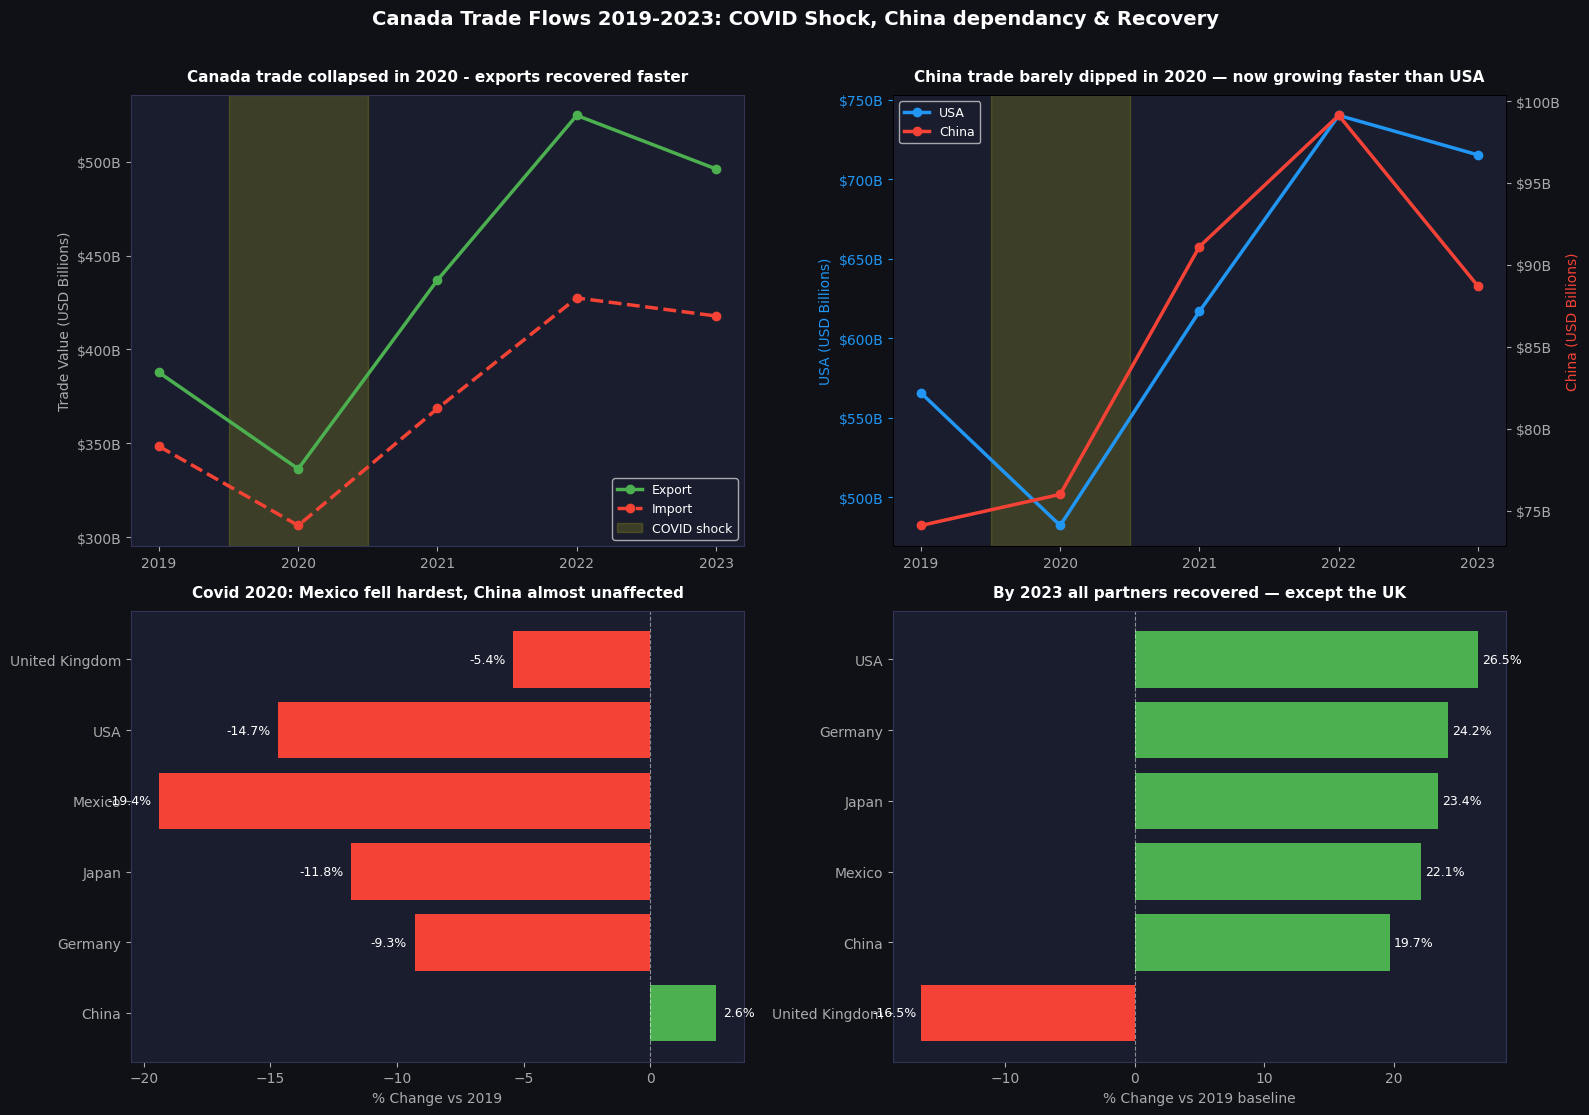

Saved: canada_trade_analysis.png


In [28]:
partners = {'USA','China','Germany','Japan', 'Mexico','United Kingdom'}
colors = {'USA':'#2196F3', 'China':'#F44336','Germany':'#4CAF50','Japan':'#FF9800','Mexico':'#9C27B0','United Kingdom':'#00BCD4'}

fig, axes = plt.subplots(2,2,figsize=(16,11))
fig.patch.set_facecolor('#0F1117')
for ax in axes.flatten(): 
    ax.set_facecolor('#1A1D2E')
    ax.tick_params(colors='#AAAAAA')
    ax.xaxis.label.set_color('#AAAAAA')
    ax.yaxis.label.set_color('#AAAAAA')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

# ── CHART 1: Total trade by year — the COVID dip ──
ax1 = axes[0,0]
yearly_total = df_clean.groupby(['year','flow'])['value_usd'].sum().reset_index()
for flow, color, ls in [('Export','#4CAF50','-'), ('Import','#F44335','--')]: 
    d = yearly_total[yearly_total['flow']== flow].sort_values('year')
    ax1.plot(d['year'],d['value_usd']/1e9,color=color,linewidth=2.5, linestyle =ls, marker ='o', markersize = '6',label= flow)
ax1.axvspan(2019.5,2020.5,alpha = 0.15, color='yellow',label ='COVID shock')
ax1.set_title('Canada trade collapsed in 2020 - exports recovered faster', color = 'white', fontsize= 11, fontweight='bold', pad = 10)
ax1.set_ylabel('Trade Value (USD Billions)',color = '#AAAAAA')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
ax1.legend(facecolor='#1A1D2E',labelcolor = 'white',fontsize = 9)
ax1.set_xticks([2019,2020,2021,2022,2023])


# ── CHART 2: China vs USA trade over time ──
ax2 = axes[0,1]
partner_yearly = df_clean.groupby(['year','country'])['value_usd'].sum().reset_index()

# Create second y-axis for China so both lines are readable
ax2_twin = ax2.twinx()

# USA on left axis, China on right axis
for p, ax_use in [('USA', ax2), ('China', ax2_twin)]:
    d = partner_yearly[partner_yearly['country']==p].sort_values('year')
    ax_use.plot(d['year'], d['value_usd']/1e9,
                color=colors[p], linewidth=2.5,
                marker='o', markersize=6, label=p)
# Style both axes
ax2.axvspan(2019.5, 2020.5, alpha=0.15, color='yellow')
ax2.set_title('China trade barely dipped in 2020 — now growing faster than USA',
              color='white', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('USA (USD Billions)', color='#2196F3')
ax2_twin.set_ylabel('China (USD Billions)', color='#F44336')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
ax2.tick_params(axis='y', colors='#2196F3')
ax2_twin.tick_params(colors='#AAAAAA')
ax2_twin.set_facecolor('#1A1D2E')
ax2.set_xticks([2019,2020,2021,2022,2023])
# Combine both legends into one box
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           facecolor='#1A1D2E', labelcolor='white', fontsize=9)


# ── CHART 3: COVID shock % drop by partner ──

ax3= axes[1,0]
p19 = partner_yearly[partner_yearly['year']==2019].set_index('country')['value_usd']
p20 = partner_yearly[partner_yearly['year']==2020].set_index('country')['value_usd']
shock = pd.DataFrame({'v2019':p19,'v2020':p20}).dropna()
shock['pct_change'] = ((shock['v2020']-shock['v2019'])/shock['v2019']*100).round(1)
shcok = shock.sort_values('pct_change')
bar_colors = ['#F44336' if x < 0 else '#4CAF50' for x in shock['pct_change']]
bars = ax3.barh(shock.index,shock['pct_change'],color=bar_colors,edgecolor= 'none')
ax3.axvline(0,color='white',linewidth=0.8,linestyle='--',alpha=0.5)
ax3.set_title('Covid 2020: Mexico fell hardest, China almost unaffected',color ='white',fontsize=11,fontweight='bold',pad=10)
ax3.set_xlabel('% Change vs 2019', color= '#AAAAAA')
for bar, val in zip(bars, shock['pct_change']):
    ax3.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', ha='left' if val >= 0 else 'right',
             color='white', fontsize=9)

# ── CHART 4: 2023 recovery vs 2019 baseline ──

ax4 = axes[1,1] # choosing bottom right(4th) chart
p23 = partner_yearly[partner_yearly['year'] == 2023].set_index('country')['value_usd'] # set_index('country) allows country to become lookup label and then selecting value_usd
recovery = pd.DataFrame({'v2019':p19, 'v2023':p23}).dropna() # create dataframe using p19 and p23
recovery['pct_change'] = ((recovery['v2023'] - recovery['v2019'])/recovery['v2019']*100).round(1) # calculate % 
recovery = recovery.sort_values('pct_change') # sort values lowest to highest 
bar_colors2 = ['#F44336' if x < 0 else '#4CAF50' for x in recovery['pct_change']] # Assign red to negative changes and green to positive or zero changes
bars2 = ax4.barh(recovery.index, # countries on Y axis 
                 recovery['pct_change'], # bar sizes
                 color=bar_colors2, # red or green as defines in bar_colors2
                 edgecolor='none') # no bar borders
ax4.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax4.set_title('By 2023 all partners recovered — except the UK',
              color='white', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('% Change vs 2019 baseline', color='#AAAAAA')
for bar, val in zip(bars2, recovery['pct_change']):
    ax4.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', ha='left' if val >= 0 else 'right',
             color='white', fontsize=9)

plt.suptitle('Canada Trade Flows 2019-2023: COVID Shock, China dependancy & Recovery', color='white',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('canada_trade_analysis.png',dpi=150, bbox_inches = 'tight', facecolor='#0F1117')
plt.show()
print('Saved: canada_trade_analysis.png')